In [61]:
import requests
import numpy as np
import pandas as pd
from datetime import datetime

hoy = datetime.today()
fecha_hoy = hoy.strftime("%Y%m%d")

url = "https://www.loteriasyapuestas.es/servicios/buscadorSorteos"

headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64)",
    "Accept": "application/json, text/javascript, */*; q=0.01",
    "Referer": "https://www.loteriasyapuestas.es/"
}
##################################################################
rangos = [
    ("20040101", "20080101"),
    ("20080101", "20120101"),
    ("20120101", "20160101"),
    ("20160101", "20200101"),
    ("20200101", "20230101"),
    #("20230101", "20260324"),
    ("20230101", fecha_hoy),
]

# --- Descarga ---
todos = []

for inicio, fin in rangos:
    print(f"Descargando {inicio} → {fin}")
    
    params = {
        "game_id": "EMIL",
        "celebrados": "true",
        "fechaInicioInclusiva": inicio,
        "fechaFinInclusiva": fin
    }
    
    response = requests.get(url, params=params, headers=headers)
    
    if response.status_code != 200:
        print(f"Error en rango {inicio}-{fin}")
        continue
    
    data = response.json()
    
    print(f"  → {len(data)} sorteos")
    
    todos.extend(data)

# --- DataFrame ---
df = pd.json_normalize(todos)

# --- Limpieza básica ---
df = df.drop_duplicates(subset=["fecha_sorteo", "premio_bote"])

print(f"\nTotal sorteos: {len(df)}")

df.head()
###################################################################
#response = requests.get(url, params=params, headers=headers)

#print(response.status_code)
#print(response.headers.get("content-type"))
#print(response.text[:300])  #DEBUG

#data = response.json()
#df = pd.json_normalize(data)  #Pasa de API(estructura arbol) a DataFrame (estructura tabla)
#df.columns
#print(df.head(5))

Descargando 20040101 → 20080101
  → 115 sorteos
Descargando 20080101 → 20120101
  → 115 sorteos
Descargando 20120101 → 20160101
  → 115 sorteos
Descargando 20160101 → 20200101
  → 115 sorteos
Descargando 20200101 → 20230101
  → 115 sorteos
Descargando 20230101 → 20260330
  → 115 sorteos

Total sorteos: 690


,fecha_sorteo,dia_semana,id_sorteo,game_id,anyo,numero,premio_bote,cdc,apuestas,recaudacion,...,millon.gameid,millon.relsorteoid_asociado,millon.combinacion,millon.importe,millon.activo,lluvia.gameid,lluvia.relsorteoid_asociado,lluvia.combinacion,lluvia.importe,lluvia.activo
0,2007-12-28 21:30:00,viernes,639002001,EMIL,2007,1,0,6390,7787067,1557413400,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2007-12-21 21:30:00,viernes,638302001,EMIL,2007,1,0,6383,8381966,1676393200,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2007-12-14 21:30:00,viernes,637602001,EMIL,2007,1,0,6376,7911567,1582313400,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2007-12-07 21:30:00,viernes,636902001,EMIL,2007,1,0,6369,8130543,1626108600,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2007-11-30 21:30:00,viernes,636202001,EMIL,2007,1,0,6362,7768269,1553653800,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [2]:
#df.isnull().sum()

In [3]:
euromillones = df.loc[:,['fecha_sorteo','dia_semana','game_id','anyo','numero', 'premio_bote','apuestas','recaudacion','combinacion','premios','fondo_bote','millon.gameid','millon.relsorteoid_asociado','millon.combinacion','millon.activo']]

In [4]:
euromillones.head(2)

,fecha_sorteo,dia_semana,game_id,anyo,numero,premio_bote,apuestas,recaudacion,combinacion,premios,fondo_bote,millon.gameid,millon.relsorteoid_asociado,millon.combinacion,millon.activo
0,2007-12-28 21:30:00,viernes,EMIL,2007,1,0,7787067,1557413400,20 - 21 - 22 - 31 - 45 - 07 - 09,778706700,0,NaN,NaN,NaN,NaN
1,2007-12-21 21:30:00,viernes,EMIL,2007,1,0,8381966,1676393200,07 - 09 - 28 - 37 - 44 - 06 - 07,838196600,0,NaN,NaN,NaN,NaN


In [5]:
euromillones = euromillones.drop(columns=['game_id','millon.gameid','millon.relsorteoid_asociado']) #Esto no da nada

In [6]:
euromillones.head(2)

,fecha_sorteo,dia_semana,anyo,numero,premio_bote,apuestas,recaudacion,combinacion,premios,fondo_bote,millon.combinacion,millon.activo
0,2007-12-28 21:30:00,viernes,2007,1,0,7787067,1557413400,20 - 21 - 22 - 31 - 45 - 07 - 09,778706700,0,NaN,NaN
1,2007-12-21 21:30:00,viernes,2007,1,0,8381966,1676393200,07 - 09 - 28 - 37 - 44 - 06 - 07,838196600,0,NaN,NaN


In [7]:
euromillones.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 690 entries, 0 to 689
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   fecha_sorteo        690 non-null    object
 1   dia_semana          690 non-null    object
 2   anyo                690 non-null    object
 3   numero              690 non-null    int64 
 4   premio_bote         690 non-null    object
 5   apuestas            690 non-null    object
 6   recaudacion         690 non-null    object
 7   combinacion         690 non-null    object
 8   premios             690 non-null    object
 9   fondo_bote          690 non-null    object
 10  millon.combinacion  331 non-null    object
 11  millon.activo       331 non-null    object
dtypes: int64(1), object(11)
memory usage: 64.8+ KB


In [8]:
euromillones['anyo'] = euromillones.anyo.astype('int64')
euromillones['premio_bote'] = euromillones.premio_bote.astype('int64')
euromillones['apuestas'] = euromillones.apuestas.astype('int64')
euromillones['recaudacion'] = euromillones.recaudacion.astype('int64') 
euromillones['premios'] = euromillones.premios.astype('int64')
euromillones['fondo_bote'] = euromillones.fondo_bote.astype('int64')
#euromillones['millon.relsorteoid_asociado'] = euromillones['millon.relsorteoid_asociado'].astype('int64')
#euromillones['millon.activo'] = euromillones['millon.activo'].astype('int64') 
euromillones.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 690 entries, 0 to 689
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   fecha_sorteo        690 non-null    object
 1   dia_semana          690 non-null    object
 2   anyo                690 non-null    int64 
 3   numero              690 non-null    int64 
 4   premio_bote         690 non-null    int64 
 5   apuestas            690 non-null    int64 
 6   recaudacion         690 non-null    int64 
 7   combinacion         690 non-null    object
 8   premios             690 non-null    int64 
 9   fondo_bote          690 non-null    int64 
 10  millon.combinacion  331 non-null    object
 11  millon.activo       331 non-null    object
dtypes: int64(7), object(5)
memory usage: 64.8+ KB


In [9]:
euromillones.groupby('dia_semana').recaudacion.describe()

,count,mean,std,min,25%,50%,75%,max
dia_semana,,,,,,,,
martes,264.0,1.017685e+09,2.435927e+08,672570580.0,8.639228e+08,9.372679e+08,1.089141e+09,2.226088e+09
viernes,426.0,1.507917e+09,4.414657e+08,879738200.0,1.176785e+09,1.420387e+09,1.709517e+09,3.659206e+09


In [10]:
euromillones['millon.combinacion'] = euromillones['millon.combinacion'].fillna(0)
euromillones['millon.activo'] = euromillones['millon.activo'].fillna(0)

In [11]:
euromillones.groupby('premio_bote').apuestas.count().sort_values()

premio_bote
96000000       1
115000000      1
112000000      1
111000000      1
110000000      1
            ... 
130000000     11
26000000      12
15000000      16
17000000      50
0            272
Name: apuestas, Length: 140, dtype: int64

In [12]:
euromillones[euromillones['premio_bote']==0].sample(2)
#Hay Botes de 0!! no tiene sentido, el minimo es 17000000

,fecha_sorteo,dia_semana,anyo,numero,premio_bote,apuestas,recaudacion,combinacion,premios,fondo_bote,millon.combinacion,millon.activo
264,2015-09-04 21:21:00,viernes,2015,71,0,5726863,1145372600,08 - 09 - 27 - 45 - 50 - 08 - 10,572686300,1500000000,0,0
44,2007-02-23 21:30:00,viernes,2007,1,0,0,1623867800,02 - 15 - 18 - 20 - 22 - 02 - 05,0,0,0,0


In [13]:
len(euromillones)

690

In [14]:
euromillones_bote = euromillones[euromillones['premio_bote']>0]
len(euromillones_bote)

418

In [15]:
euromillones_bote.groupby('premio_bote').apuestas.describe()

,count,mean,std,min,25%,50%,75%,max
premio_bote,,,,,,,,
15000000,16.0,6.030771e+06,1.813181e+06,4357740.0,4984124.75,5255437.5,6485768.75,9892991.0
17000000,50.0,4.377443e+06,8.723168e+05,3386176.0,3632801.00,4231081.0,4901245.25,8291366.0
21000000,2.0,5.697177e+06,5.373248e+05,5317231.0,5507204.00,5697177.0,5887150.00,6077123.0
24000000,2.0,3.879046e+06,1.328060e+05,3785138.0,3832092.00,3879046.0,3926000.00,3972954.0
25000000,10.0,4.401918e+06,1.528228e+06,3691131.0,3808185.25,4007300.0,4025862.25,8729376.0
...,...,...,...,...,...,...,...,...
230000000,4.0,7.866414e+06,8.025045e+05,7163241.0,7184032.50,7811039.5,8493420.50,8680334.0
234000000,1.0,6.217273e+06,NaN,6217273.0,6217273.00,6217273.0,6217273.00,6217273.0
237000000,1.0,6.930100e+06,NaN,6930100.0,6930100.00,6930100.0,6930100.00,6930100.0


<Axes: title={'center': 'apuestas'}, xlabel='premio_bote'>

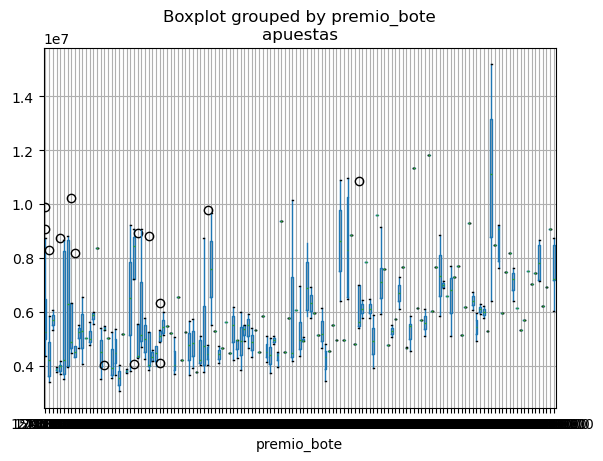

In [16]:
euromillones_bote.boxplot(column='apuestas', by = 'premio_bote')

In [17]:
euromillones_bote.fecha_sorteo

115    2011-12-30 21:30:00
116    2011-12-27 21:30:00
117    2011-12-23 21:30:00
118    2011-12-20 21:30:00
119    2011-12-16 21:30:00
              ...         
685    2025-03-04 21:08:00
686    2025-02-28 21:13:00
687    2025-02-25 21:16:00
688    2025-02-21 21:25:00
689    2025-02-18 21:14:00
Name: fecha_sorteo, Length: 418, dtype: object

In [18]:
euromillones_bote["fecha_sorteo"] = pd.to_datetime(
    euromillones_bote["fecha_sorteo"].astype(str).str.strip(),
    errors="coerce")

C:\Users\marco\AppData\Local\Temp\ipykernel_40732\2013192737.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  euromillones_bote["fecha_sorteo"] = pd.to_datetime(


In [19]:
euromillones_bote.fecha_sorteo

115   2011-12-30 21:30:00
116   2011-12-27 21:30:00
117   2011-12-23 21:30:00
118   2011-12-20 21:30:00
119   2011-12-16 21:30:00
              ...        
685   2025-03-04 21:08:00
686   2025-02-28 21:13:00
687   2025-02-25 21:16:00
688   2025-02-21 21:25:00
689   2025-02-18 21:14:00
Name: fecha_sorteo, Length: 418, dtype: datetime64[ns]

In [20]:
euromillones_bote.loc[:,'Mes'] = euromillones_bote['fecha_sorteo'].dt.month_name()

C:\Users\marco\AppData\Local\Temp\ipykernel_40732\1825374721.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  euromillones_bote.loc[:,'Mes'] = euromillones_bote['fecha_sorteo'].dt.month_name()


In [21]:
euromillones_bote.groupby('Mes').apuestas.median()
#Parece que se juega menos en Abril!!! En Junio y Septiembre cuando mas

Mes
April        4464502.0
August       5265943.5
December     4824103.0
February     4777133.0
January      4734992.0
July         5511411.5
June         5980629.0
March        5030114.0
May          5057415.0
November     5180768.0
October      5381469.0
September    6461676.0
Name: apuestas, dtype: float64

<Axes: title={'center': 'apuestas'}, xlabel='Mes'>

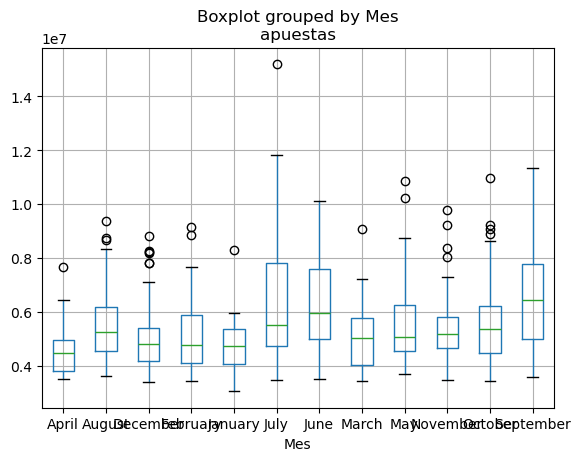

In [22]:
euromillones_bote.boxplot(column='apuestas', by='Mes')

In [23]:
euromillones_bote.groupby('Mes').premio_bote.describe()
#Abril no tiene botes demasiado altos!!

,count,mean,std,min,25%,50%,75%,max
Mes,,,,,,,,
April,27.0,6.251852e+07,3.869642e+07,17000000.0,29000000.0,59000000.0,82000000.0,158000000.0
August,36.0,8.772222e+07,6.224588e+07,15000000.0,44500000.0,74500000.0,102000000.0,250000000.0
December,54.0,5.220370e+07,3.927137e+07,15000000.0,25000000.0,39000000.0,69500000.0,143000000.0
February,29.0,7.324138e+07,5.485022e+07,17000000.0,29000000.0,52000000.0,130000000.0,176000000.0
January,26.0,5.884615e+07,3.210195e+07,17000000.0,32250000.0,53500000.0,77750000.0,128000000.0
July,36.0,1.026111e+08,7.366227e+07,15000000.0,34000000.0,88000000.0,156750000.0,230000000.0
June,33.0,1.026667e+08,7.704733e+07,17000000.0,39000000.0,76000000.0,139000000.0,250000000.0
March,33.0,8.506061e+07,7.118108e+07,17000000.0,32000000.0,50000000.0,143000000.0,243000000.0
May,35.0,8.094286e+07,6.957854e+07,15000000.0,25000000.0,44000000.0,130500000.0,221000000.0


In [24]:
euromillones_bote.groupby('Mes')[ ['apuestas','premio_bote'] ].mean()

,apuestas,premio_bote
Mes,,
April,4.624157e+06,6.251852e+07
August,5.582755e+06,8.772222e+07
December,5.100237e+06,5.220370e+07
February,5.292319e+06,7.324138e+07
January,4.816156e+06,5.884615e+07
July,6.487455e+06,1.026111e+08
June,6.419310e+06,1.026667e+08
March,5.140857e+06,8.506061e+07
May,5.719138e+06,8.094286e+07


<Axes: xlabel='premio_bote', ylabel='apuestas'>

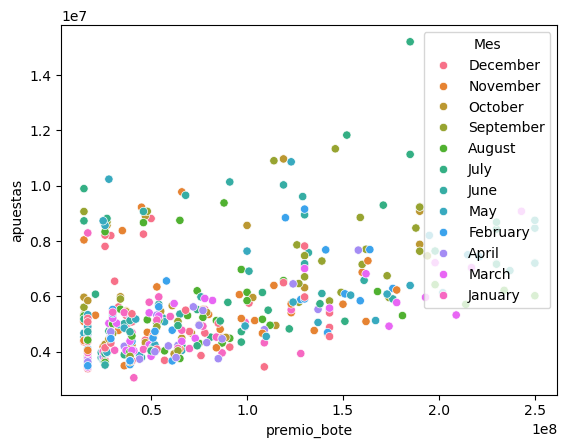

In [25]:
import seaborn as sns
sns.scatterplot(data=euromillones_bote, x="premio_bote", y="apuestas", hue="Mes")

In [26]:
euromillones_bote['millon_probabilidad'] = 1/euromillones_bote['apuestas']
#Probabilidad del millon

C:\Users\marco\AppData\Local\Temp\ipykernel_40732\3532729513.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  euromillones_bote['millon_probabilidad'] = 1/euromillones_bote['apuestas']


In [27]:
euromillones_bote.loc[:,'dia_anyo'] = euromillones_bote['fecha_sorteo'].dt.dayofyear

C:\Users\marco\AppData\Local\Temp\ipykernel_40732\1953326134.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  euromillones_bote.loc[:,'dia_anyo'] = euromillones_bote['fecha_sorteo'].dt.dayofyear


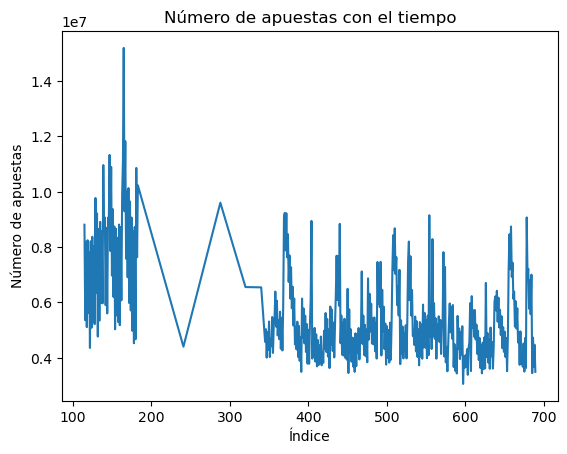

In [28]:
import matplotlib.pyplot as plt
plt.plot(euromillones_bote['apuestas'])
plt.xlabel('Índice')
plt.ylabel('Número de apuestas')
plt.title('Número de apuestas con el tiempo')
plt.show()

<Axes: title={'center': 'apuestas'}, xlabel='dia_anyo'>

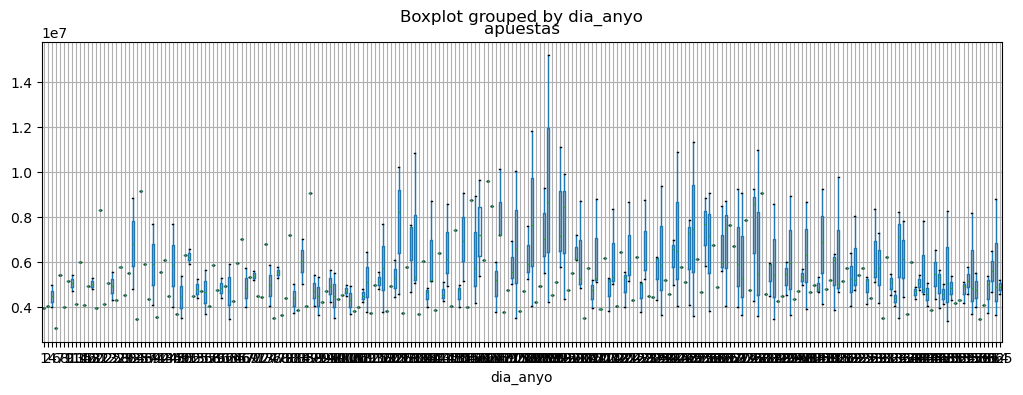

In [64]:
euromillones_bote.boxplot(column='apuestas', by='dia_anyo', figsize=(12,4))

In [30]:
euromillones_bote.columns

Index(['fecha_sorteo', 'dia_semana', 'anyo', 'numero', 'premio_bote',
       'apuestas', 'recaudacion', 'combinacion', 'premios', 'fondo_bote',
       'millon.combinacion', 'millon.activo', 'Mes', 'millon_probabilidad',
       'dia_anyo'],
      dtype='object')

In [31]:
Y = euromillones_bote.apuestas

In [32]:
columns = ['premio_bote','dia_anyo','dia_semana']
X = euromillones_bote[columns]

In [33]:
#El dia de la semana es ciclico en el año!! Introducir dos variables sin y cos para recrear ese 'circulo'
X['dia_anyo_sin'] = np.sin(2 * np.pi * X['dia_anyo'] / 365)
X['dia_anyo_cos'] = np.cos(2 * np.pi * X['dia_anyo'] / 365)
X = X.drop(columns=['dia_anyo'])

C:\Users\marco\AppData\Local\Temp\ipykernel_40732\1862820262.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['dia_anyo_sin'] = np.sin(2 * np.pi * X['dia_anyo'] / 365)
C:\Users\marco\AppData\Local\Temp\ipykernel_40732\1862820262.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['dia_anyo_cos'] = np.cos(2 * np.pi * X['dia_anyo'] / 365)


In [34]:
X = pd.get_dummies(X, columns=['dia_semana'], drop_first=True)

# Models

In [35]:
from sklearn.model_selection import train_test_split

# 80% entrenamiento, 20% test
X_train, X_test, y_train, y_test = train_test_split( X, Y, test_size=0.2, random_state=42)

In [36]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

lr = LinearRegression()
lr.fit(X_train, y_train)

# Predicciones
y_pred_lr = lr.predict(X_test)

# Error
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
print(f"RMSE Linear Regression: {rmse_lr}")

RMSE Linear Regression: 1360224.784933211


In [37]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
print(f"RMSE Random Forest: {rmse_rf}")

RMSE Random Forest: 1253005.730800759


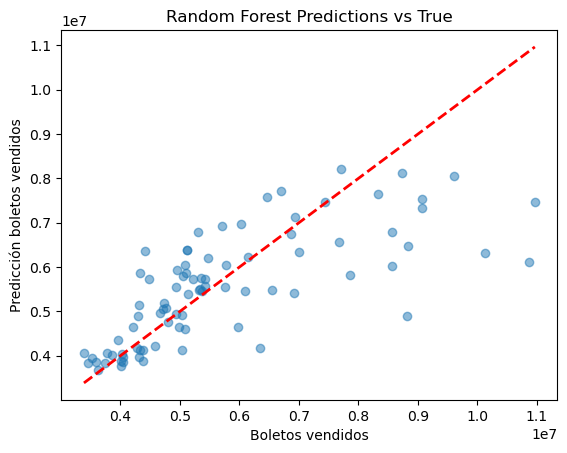

In [38]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred_rf, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)  # function y=x
plt.xlabel("Boletos vendidos")
plt.ylabel("Predicción boletos vendidos")
plt.title("Random Forest Predictions vs True")
plt.show()

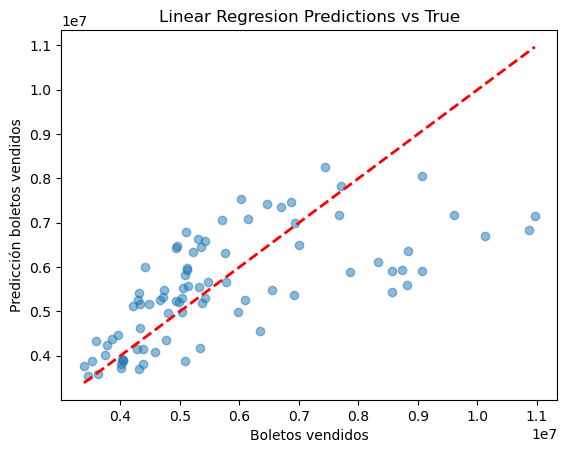

In [39]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred_lr, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)  # function y=x
plt.xlabel("Boletos vendidos")
plt.ylabel("Predicción boletos vendidos")
plt.title("Linear Regresion Predictions vs True")
plt.show()

In [40]:
from sklearn.model_selection import cross_val_score
import numpy as np

scores = cross_val_score(rf, X, Y, scoring="neg_mean_squared_error", cv=5)
rmse_scores = np.sqrt(-scores)

print("RMSE scores:", rmse_scores)
print("Mean RMSE:", rmse_scores.mean())

RMSE scores: [3048530.89474075  862980.53367057 1455294.80108901  963321.86463046
 1388384.03347437]
Mean RMSE: 1543702.4255210327


In [41]:
#Importances in RF
importances = rf.feature_importances_
features = X.columns

feat_imp = pd.Series(importances, index=features).sort_values(ascending=False)
print(feat_imp.head(15))
#print(feat_imp.tail(15))

premio_bote           0.508388
dia_semana_viernes    0.182833
dia_anyo_cos          0.160622
dia_anyo_sin          0.148157
dtype: float64


In [42]:
#Coefficients in linear regresion
coeffs = pd.Series(lr.coef_, index=X.columns).sort_values(ascending=False)
print(coeffs.head(15))
#print(coeffs.tail(15))

dia_semana_viernes    1.495171e+06
premio_bote           1.296875e-02
dia_anyo_cos         -3.415982e+05
dia_anyo_sin         -3.639082e+05
dtype: float64


In [43]:
euromillones_bote.millon_probabilidad.max()

3.271032164386376e-07

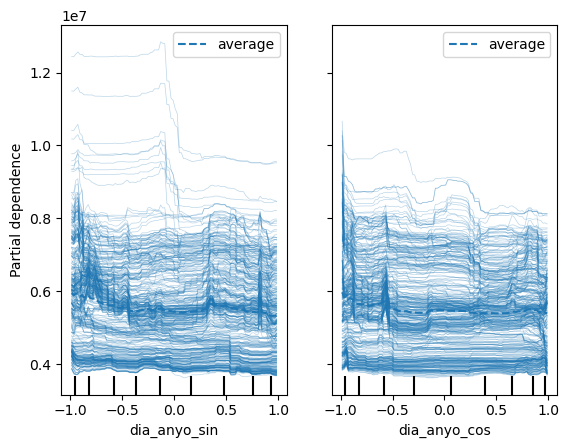

In [44]:
#Partial dependence random forest
from sklearn.inspection import PartialDependenceDisplay
import matplotlib.pyplot as plt

# Asumiendo que tu modelo está en 'rf_model' y tus datos en X
features = ['dia_anyo_sin', 'dia_anyo_cos']

PartialDependenceDisplay.from_estimator(rf, X, features, kind='both', grid_resolution=100)
plt.show()

In [45]:
# Grid del año
grid = np.linspace(0, 2*np.pi, 100)

# Crear base con mismas columnas que X
df_plot = pd.DataFrame(np.tile(X.mean(), (100,1)), columns=X.columns)

# Variables cíclicas
df_plot['dia_anyo_sin'] = np.sin(grid)
df_plot['dia_anyo_cos'] = np.cos(grid)

# Bote medio
bote_medio = X['premio_bote'].mean()
df_plot['premio_bote'] = bote_medio

# MARTES
df_plot['dia_semana_viernes'] = 0
pred_martes = rf.predict(df_plot)

# VIERNES
df_plot['dia_semana_viernes'] = 1
pred_viernes = rf.predict(df_plot)

# Convertir a día del año
df_plot['dia'] = grid * (365 / (2*np.pi))

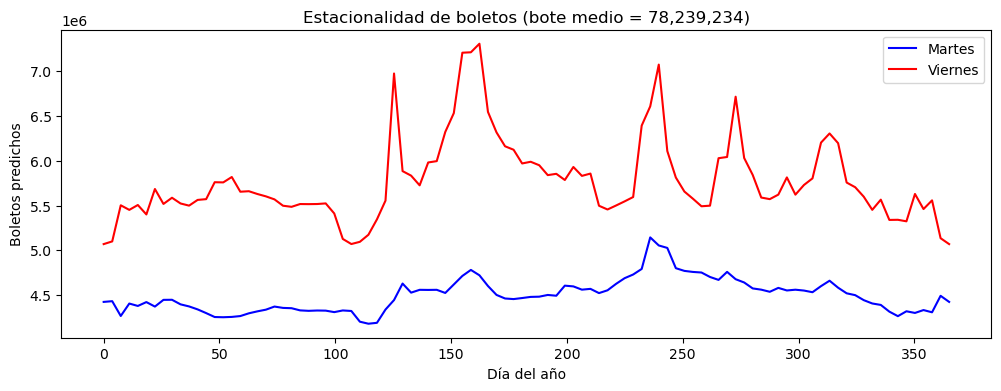

In [46]:
# Plot
plt.figure(figsize=(12,4))

plt.plot(df_plot['dia'], pred_martes, label='Martes', color='blue')
plt.plot(df_plot['dia'], pred_viernes, label='Viernes', color='red')

plt.xlabel('Día del año')
plt.ylabel('Boletos predichos')
plt.title(f'Estacionalidad de boletos (bote medio = {bote_medio:,.0f})')

plt.legend()
plt.show()

PARA UN BOTE MEDIO DE 78 MILLONES DE EUROS EL MARTES JUEGA MUCHA MENOS GENTE DE MEDIA (YA SE VEÍA CON GROUPBY EN DIA DE SEMANA DESDE EL DATAFRAME)
VAYAMOS AHORA SIMPLEMENTE AL JUEGO MEDIO DE LOS MARTES PARA CAPTAR MÍNIMOS SEGUN ESTACIONALIDAD

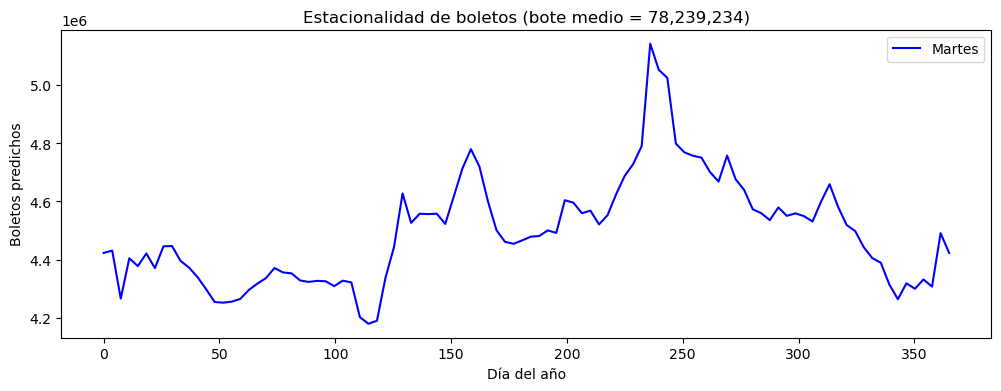

In [47]:
# Plot solo martes
plt.figure(figsize=(12,4))

plt.plot(df_plot['dia'], pred_martes, label='Martes', color='blue')

plt.xlabel('Día del año')
plt.ylabel('Boletos predichos')
plt.title(f'Estacionalidad de boletos (bote medio = {bote_medio:,.0f})')

plt.legend()
plt.show()

In [48]:
df_plot.columns

Index(['premio_bote', 'dia_anyo_sin', 'dia_anyo_cos', 'dia_semana_viernes',
       'dia'],
      dtype='object')

In [57]:
idx_min = pred_martes.argmin()  #Indice del valor minimo de boletos
dia_min = df_plot['dia'].iloc[idx_min]  #Dia con ese valor minimo
valor_min = pred_martes[idx_min]

idx_max = pred_martes.argmax()
dia_max = df_plot['dia'].iloc[idx_max]
valor_max = pred_martes[idx_max]

In [62]:
print(f'El día (martes) con menos boletos vendidos es aquel cerca del día {int(dia_min)}.')
print(f'Ese día se venden alrededor de {int(valor_min)} boletos según el modelo.')
print(f'Por el contrario, el día (martes) con más boletos vendidos es cerca del día {int(dia_max)}.')
print(f'Ese día se venden alrededor de {int(valor_max)} boletos.')

El día (martes) con menos boletos vendidos es aquel cerca del día 114.
Ese día se venden alrededor de 4178872 boletos según el modelo.
Por el contrario, el día (martes) con más boletos vendidos es cerca del día 235.
Ese día se venden alrededor de 5143512 boletos.


TAL COMO SE HABIA VISTO EN LA GRAFICA AGRUPANDO BOLETOS POR MESES EL MINIMO SE DA EN ABRIL (EL DIA 114 ES ~20 DE ABRIL, *YA NOS LO DECIAN LOS CELTAS CORTOS...*)